# ISS Reference Orbit with FORMS

FORMS configures and propagates one circular, ISS-like orbit. The only custom simulation code is a FORMS-compatible routine that evaluates an aligned dipole magnetic-field model at the live spacecraft position.

> The installed FORMS SDK exposes `rk45`, its fixed-step Dormand-Prince RK4(5) propagator. It does not expose a separate propagator named `rk4`.

In [ ]:
import inspect
import math
import sys
from pathlib import Path

import numpy as np
from forms import FORMS
from forms.sequence import Segment, Sequence, SequenceRunner

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.routines import SampleDipoleMagneticFieldRoutine

python_path = Path(sys.executable).resolve()

print("Python executable:", python_path)

## Configure the FORMS mission

The orbit, clock, point-mass force model, integrator, and state history are all FORMS SDK objects.

In [12]:
EARTH_RADIUS_KM = 6378.137
ISS_ALTITUDE_KM = 408.0
ISS_INCLINATION_DEG = 51.64
REQUESTED_STEP_S = 10.0

forms_handle = FORMS()
forms_handle.load_koe(
    a=EARTH_RADIUS_KM + ISS_ALTITUDE_KM,
    e=0.0,
    i=ISS_INCLINATION_DEG,
    raan=0.0,
    aop=0.0,
    ta=0.0,
    timestamp="2026:06:30:00:00:00",
)

orbit_period_s = forms_handle.orbit.period
orbit_step_count = math.ceil(orbit_period_s / REQUESTED_STEP_S)
fixed_step_s = orbit_period_s / orbit_step_count

forms_handle.time.set_span(
    mode="simulated",
    duration=orbit_period_s,
    units="seconds",
)
forms_handle.satellite.force_model.set_gravity("point_mass")
forms_handle.satellite.propagator_config.set_type("rk45")
forms_handle.satellite.propagator_config.set_mode(
    "simulated",
    fixed_dt=fixed_step_s,
)
forms_handle.satellite.propagator_config.set_history(True)
forms_handle.satellite.propagator_config.apply()
forms_handle.recording = False

initial_state = np.array(forms_handle.satellite.get_orbital_state(), dtype=float)

print(f"FORMS orbit period: {orbit_period_s / 60.0:.3f} min")
print(f"Fixed RK4(5) step: {fixed_step_s:.6f} s")
print(f"Expected propagation steps: {orbit_step_count}")

[2026-07-12 17:58:43.447] [FORMS] [WARNING] EOP data not available - transforms will use default values
[2026-07-12 17:58:43.451] [Propagator] [INFO] Force model: <ForceModel gravity=point_mass>
FORMS orbit period: 92.724 min
Fixed RK4(5) step: 9.988257 s
Expected propagation steps: 557


## Custom FORMS routine

The routine is a class-based object that holds the active FORMS handle and exposes a zero-argument `step()` method for the sequence runner.

In [13]:
field_samples = []
magnetic_routine = SampleDipoleMagneticFieldRoutine(
    forms_handle,
    earth_radius_km=EARTH_RADIUS_KM,
    equatorial_surface_field_nt=31_200.0,
    dipole_axis_gcrs=[0.0, 0.0, 1.0],
    samples=field_samples,
)

## Run one orbit

The standard FORMS sequence runner advances the satellite and calls the custom routine at each simulation tick.

In [14]:
sequence = Sequence(
    name="iss_one_orbit",
    segments=(
        Segment("propagate", {"stop": None}, label="propagate -- full span"),
    ),
)
runner_params = inspect.signature(SequenceRunner).parameters
runner_callback_kw = (
    {"routine": magnetic_routine.step}
    if "routine" in runner_params
    else {"tick": magnetic_routine.step}
)
runner = SequenceRunner(forms_handle, sequence, **runner_callback_kw)
run_result = runner.run()

propagator = forms_handle.satellite.propagator
propagated_steps = len(propagator.solution_t) - 1

print(f"FORMS propagation steps: {propagated_steps}")
print(f"Custom field samples: {len(field_samples)}")

FORMS propagation steps: 557
Custom field samples: 558


In [15]:
final_state = np.array(forms_handle.satellite.get_orbital_state(), dtype=float)
position_closure_m = np.linalg.norm(final_state[:3] - initial_state[:3]) * 1000.0
velocity_closure_mps = np.linalg.norm(final_state[3:] - initial_state[3:]) * 1000.0
field_magnitudes_nt = np.array(
    [sample["magnitude_nt"] for sample in field_samples],
    dtype=float,
)
elapsed_s = (forms_handle.time.epoch - forms_handle.time.epoch0) * 86400.0

print(f"Elapsed simulation time: {elapsed_s:.6f} s")
print(f"Position closure error: {position_closure_m:.3f} m")
print(f"Velocity closure error: {velocity_closure_mps:.6f} m/s")
print(
    "Custom magnetic-field range: "
    f"{field_magnitudes_nt.min():.1f} to {field_magnitudes_nt.max():.1f} nT"
)

Elapsed simulation time: 5563.459297 s
Position closure error: 0.017 m
Velocity closure error: 0.000019 m/s
Custom magnetic-field range: 25904.1 to 43689.3 nT


In [16]:
sample_count = 8
sample_indices = np.linspace(0, len(field_samples) - 1, sample_count, dtype=int)

sample_rows = [
    {
        "time_min": round(field_samples[index]["time_s"] / 60.0, 3),
        "x_km": round(float(field_samples[index]["position_km"][0]), 3),
        "y_km": round(float(field_samples[index]["position_km"][1]), 3),
        "z_km": round(float(field_samples[index]["position_km"][2]), 3),
        "field_magnitude_nt": round(field_samples[index]["magnitude_nt"], 1),
    }
    for index in sample_indices
]

sample_rows

[{'time_min': 0.0,
  'x_km': 6786.137,
  'y_km': 0.0,
  'z_km': 0.0,
  'field_magnitude_nt': 25904.1},
 {'time_min': 13.151,
  'x_km': 4265.199,
  'y_km': 3275.674,
  'z_km': -4138.804,
  'field_magnitude_nt': 37680.4},
 {'time_min': 26.469,
  'x_km': -1499.394,
  'y_km': 4107.394,
  'z_km': -5189.681,
  'field_magnitude_nt': 42992.3},
 {'time_min': 39.62,
  'x_km': -6090.176,
  'y_km': 1857.806,
  'z_km': -2347.333,
  'field_magnitude_nt': 30197.4},
 {'time_min': 52.938,
  'x_km': -6123.556,
  'y_km': -1815.054,
  'z_km': 2293.315,
  'field_magnitude_nt': 30015.4},
 {'time_min': 66.089,
  'x_km': -1573.955,
  'y_km': -4096.637,
  'z_km': 5176.088,
  'field_magnitude_nt': 42920.6},
 {'time_min': 79.407,
  'x_km': 4205.388,
  'y_km': -3305.324,
  'z_km': 4176.267,
  'field_magnitude_nt': 37860.7},
 {'time_min': 92.724,
  'x_km': 6786.137,
  'y_km': -0.0,
  'z_km': 0.0,
  'field_magnitude_nt': 25904.1}]

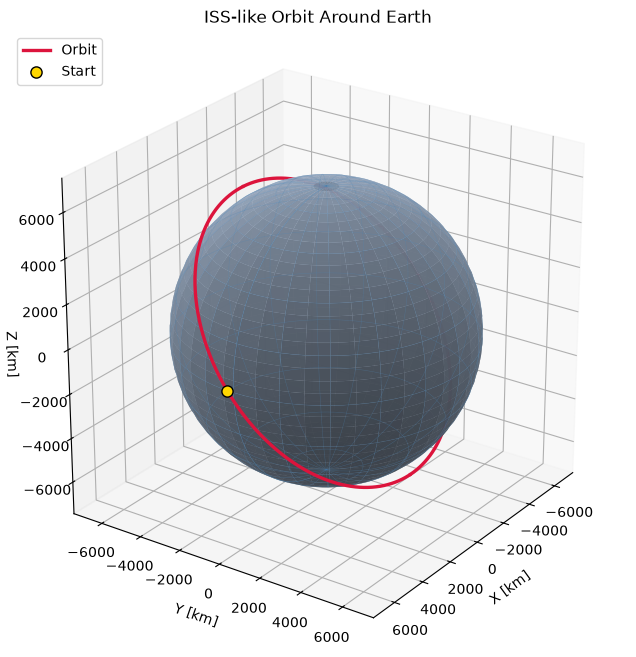

In [43]:
import numpy as np
import matplotlib.pyplot as plt

states = np.array(
    [state.flat() for state in forms_handle.satellite.propagator.solution_y],
    dtype=float,
)
positions_km = states[:, :3]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)

elev_deg = 25
azim_deg = 35

u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, np.pi, 40)
x = EARTH_RADIUS_KM * np.outer(np.cos(u), np.sin(v))
y = EARTH_RADIUS_KM * np.outer(np.sin(u), np.sin(v))
z = EARTH_RADIUS_KM * np.outer(np.ones_like(u), np.cos(v))

azim = np.deg2rad(azim_deg)
elev = np.deg2rad(elev_deg)
view_dir = np.array([
    np.cos(elev) * np.cos(azim),
    np.cos(elev) * np.sin(azim),
    np.sin(elev),
])
depth = positions_km @ view_dir
if depth[0] < 0:
    depth = -depth
front_positions = np.where((depth >= 0)[:, None], positions_km, np.nan)
back_positions = np.where((depth < 0)[:, None], positions_km, np.nan)

ax.plot(
    back_positions[:, 0],
    back_positions[:, 1],
    back_positions[:, 2],
    color="crimson",
    linewidth=2.4,
    #alpha=0.35,
    zorder=2,
)
ax.plot(
    front_positions[:, 0],
    front_positions[:, 1],
    front_positions[:, 2],
    color="crimson",
    linewidth=2.4,
    label="Orbit",
    zorder=3,
)
ax.scatter(
    positions_km[0, 0],
    positions_km[0, 1],
    positions_km[0, 2],
    color="gold",
    edgecolor="black",
    s=65,
    label="Start",
    zorder=3,
)

ax.plot_surface(
    x,
    y,
    z,
    color="lightsteelblue",
    alpha=0.88,
    linewidth=0,
    shade=True,
    zorder=2,
)
ax.plot_wireframe(
    x,
    y,
    z,
    rstride=4,
    cstride=4,
    color="steelblue",
    linewidth=0.35,
    alpha=0.35,
    zorder=2,
)

limit_km = 1.1 * np.max(np.abs(positions_km))
ax.set_xlim(-limit_km, limit_km)
ax.set_ylim(-limit_km, limit_km)
ax.set_zlim(-limit_km, limit_km)

ax.set_xlabel("X [km]")
ax.set_ylabel("Y [km]")
ax.set_zlabel("Z [km]")
ax.set_title("ISS-like Orbit Around Earth")
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=elev_deg, azim=azim_deg)
ax.legend(loc="upper left")

plt.show()